# Red Bayesiana: Diagnóstico de Aprobación de un Estudiante

Simulación probabilística para determinar si un estudiante aprueba o desaprueba una asignatura considerando:
- **Horas de estudio** (Pocas / Muchas)
- **Asistencia** (Baja / Alta)
- **Nota del examen** (Baja / Alta)
- **Aprobación** (Desaprueba / Aprueba)

Estructura de la red (Semana 5):
HorasEstudio -> Asistencia -> NotaExamen -> Aprobacion

# Red Bayesiana: Predicción del Rendimiento y Aprobación Estudiantil

## 1. Fundamento Matemático

Una Red Bayesiana es un modelo gráfico probabilístico basado en un Grafo Dirigido Acíclico (DAG) que modela relaciones de dependencia condicional e incertidumbre.

### 1.1. Teorema de Bayes
Dada una hipótesis $H$ y una evidencia observada $E$, la probabilidad a posteriori se expresa como:

$$P(H \mid E) = \frac{P(E \mid H) \cdot P(H)}{P(E)}$$

Donde:
- $P(H)$: Probabilidad a priori de la hipótesis.
- $P(E \mid H)$: Verosimilitud (probabilidad de observar la evidencia $E$ dada la hipótesis $H$).
- $P(E)$: Probabilidad total de la evidencia (factor de normalización).
- $P(H \mid E)$: Probabilidad a posteriori actualizada tras observar la evidencia.

---

### 1.2. Factorización de la Distribución Conjunta
Para el problema de diagnóstico estudiantil (Semana 5), consideramos las cuatro variables aleatorias discretas:
- $H$: Horas de Estudio $\in \{\text{Pocas}, \text{Muchas}\}$
- $A$: Asistencia $\in \{\text{Baja}, \text{Alta}\}$
- $N$: Nota del Examen $\in \{\text{Baja}, \text{Alta}\}$
- $P$: Aprobación $\in \{\text{Desaprueba}, \text{Aprueba}\}$

Aplicando la regla de la cadena y las independencias condicionales d-separadas por la topología del grafo ($H \rightarrow A \rightarrow N \rightarrow P$), la probabilidad conjunta total se factoriza como:

$$P(H, A, N, P) = P(H) \cdot P(A \mid H) \cdot P(N \mid A) \cdot P(P \mid N)$$

---

### 1.3. Inferencia por Marginalización
Para calcular la probabilidad de que un estudiante apruebe dado que estudió muchas horas y tiene asistencia alta ($P(P \mid H=\text{Muchas}, A=\text{Alta})$), se marginaliza (suma) sobre la variable no observada de la nota de examen ($N$):

$$P(P \mid H=\text{Muchas}, A=\text{Alta}) = \sum_{N} P(P \mid N) \cdot P(N \mid A=\text{Alta})$$

$$P(P=\text{Aprueba} \mid A=\text{Alta}) = P(\text{Aprueba} \mid N=\text{Alta}) P(N=\text{Alta} \mid A=\text{Alta}) + P(\text{Aprueba} \mid N=\text{Baja}) P(N=\text{Baja} \mid A=\text{Alta})$$

$$= (0.90 \times 0.80) + (0.05 \times 0.20) = 0.72 + 0.01 = 0.73 \quad (73\%)$$

---

### 1.4. Tabla Resumen: Expresión Matemática vs. Código en Python

| Concepto Matemático | Expresión Formal | Implementación en `pgmpy` |
|---|---|---|
| Probabilidad a priori | $P(H)$ | `TabularCPD(variable='HorasEstudio', ...)` |
| Probabilidad condicional | $P(A \mid H)$ | `TabularCPD(variable='Asistencia', evidence=['HorasEstudio'], ...)` |
| Distribución conjunta | $P(H, A, N, P) = \prod_{i} P(X_i \mid \text{padres}(X_i))$ | `model = DiscreteBayesianNetwork([...])` |
| Validación probabilística | $\sum_x P(X=x \mid \text{padres}) = 1.0$ | `model.check_model()` |
| Inferencia exacta | $P(A \mid E) = \frac{\sum_{\text{ocultas}} P(A, E, \text{ocultas})}{P(E)}$ | `inferencia = VariableElimination(model); inferencia.query(...)` |

In [1]:
# Importación de librerías para Redes Bayesianas y Graficación
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

print("Librerías importadas correctamente.")

c:\Users\Cristhian\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Cristhian\AppData\Local\Programs\Python\Python312\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


Librerías importadas correctamente.


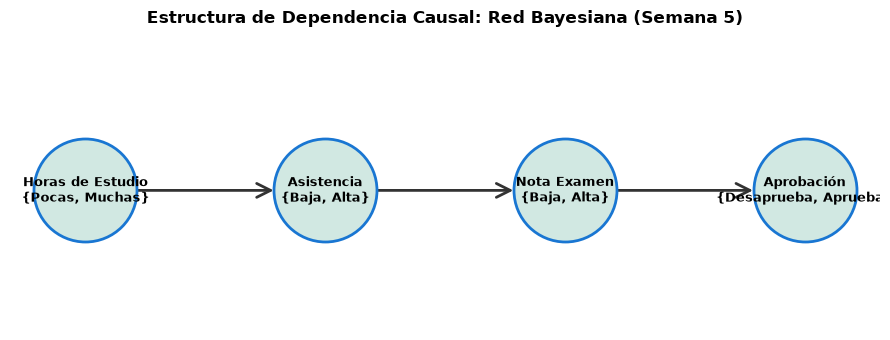

In [2]:
# Visualización gráfica de la topología de la Red Bayesiana (DAG)
plt.figure(figsize=(9, 3.5))

# Grafo dirigido con NetworkX
G = nx.DiGraph()
G.add_edges_from([
    ("Horas de Estudio\n{Pocas, Muchas}", "Asistencia\n{Baja, Alta}"),
    ("Asistencia\n{Baja, Alta}", "Nota Examen\n{Baja, Alta}"),
    ("Nota Examen\n{Baja, Alta}", "Aprobación\n{Desaprueba, Aprueba}")
])

# Posiciones lineales de izquierda a derecha
pos = {
    "Horas de Estudio\n{Pocas, Muchas}": (0, 0),
    "Asistencia\n{Baja, Alta}": (1.5, 0),
    "Nota Examen\n{Baja, Alta}": (3.0, 0),
    "Aprobación\n{Desaprueba, Aprueba}": (4.5, 0)
}

# Dibujar nodos y aristas
nx.draw_networkx_nodes(G, pos, node_size=5500, node_color="#D1E8E2", edgecolors="#1976D2", linewidths=2)
nx.draw_networkx_labels(G, pos, font_size=9, font_family="sans-serif", font_weight="bold")
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=25, edge_color="#333333", width=2, node_size=5500)

plt.title("Estructura de Dependencia Causal: Red Bayesiana (Semana 5)", fontsize=12, fontweight="bold", pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
# 1. Definición del modelo estructural
model = DiscreteBayesianNetwork([
    ("HorasEstudio", "Asistencia"),
    ("Asistencia", "NotaExamen"),
    ("NotaExamen", "Aprobacion")
])

# 2. CPD: Horas de Estudio (Raíz)
cpd_horas = TabularCPD(
    variable="HorasEstudio",
    variable_card=2,
    values=[[0.60], [0.40]],
    state_names={"HorasEstudio": ["Pocas", "Muchas"]}
)

# 3. CPD: Asistencia | HorasEstudio
cpd_asistencia = TabularCPD(
    variable="Asistencia",
    variable_card=2,
    values=[
        [0.80, 0.30],  # Baja
        [0.20, 0.70]   # Alta
    ],
    evidence=["HorasEstudio"],
    evidence_card=[2],
    state_names={
        "Asistencia": ["Baja", "Alta"],
        "HorasEstudio": ["Pocas", "Muchas"]
    }
)

# 4. CPD: Nota del Examen | Asistencia
cpd_nota = TabularCPD(
    variable="NotaExamen",
    variable_card=2,
    values=[
        [0.70, 0.20],  # Baja
        [0.30, 0.80]   # Alta
    ],
    evidence=["Asistencia"],
    evidence_card=[2],
    state_names={
        "NotaExamen": ["Baja", "Alta"],
        "Asistencia": ["Baja", "Alta"]
    }
)

# 5. CPD: Aprobación | NotaExamen
cpd_aprobacion = TabularCPD(
    variable="Aprobacion",
    variable_card=2,
    values=[
        [0.95, 0.10],  # Desaprueba
        [0.05, 0.90]   # Aprueba
    ],
    evidence=["NotaExamen"],
    evidence_card=[2],
    state_names={
        "Aprobacion": ["Desaprueba", "Aprueba"],
        "NotaExamen": ["Baja", "Alta"]
    }
)

# Ensamblado y verificación del modelo
model.add_cpds(cpd_horas, cpd_asistencia, cpd_nota, cpd_aprobacion)
assert model.check_model(), "El modelo tiene incoherencias probabilísticas."
print("Modelo ensamblado y verificado con éxito (Suma de probabilidades = 1.0).")

Modelo ensamblado y verificado con éxito (Suma de probabilidades = 1.0).


In [4]:
# Motor de inferencia analítica (Eliminación de Variables)
inferencia = VariableElimination(model)

def consultar_red(variable, evidencia=None, titulo="Consulta"):
    print("\n" + "=" * 50)
    print(titulo)
    print("=" * 50)
    resultado = inferencia.query(
        variables=[variable],
        evidence=evidencia
    )
    print(resultado)
    return resultado

In [5]:
# Escenario 1: Probabilidad a priori sin evidencia
q1 = consultar_red("Aprobacion", None, "1. A priori (Sin evidencia previa)")

# Escenario 2: Muchas horas y Asistencia alta (Caso de la diapositiva)
q2 = consultar_red("Aprobacion", {"HorasEstudio": "Muchas", "Asistencia": "Alta"}, "2. Evidencia: Muchas horas y Alta asistencia")

# Escenario 3: Pocas horas y Asistencia baja
q3 = consultar_red("Aprobacion", {"HorasEstudio": "Pocas", "Asistencia": "Baja"}, "3. Evidencia: Pocas horas y Baja asistencia")

# Escenario 4: Nota del examen Alta
q4 = consultar_red("Aprobacion", {"NotaExamen": "Alta"}, "4. Evidencia: Examen con nota alta")


1. A priori (Sin evidencia previa)
+------------------------+-------------------+
| Aprobacion             |   phi(Aprobacion) |
+========================+===================+
| Aprobacion(Desaprueba) |            0.5250 |
+------------------------+-------------------+
| Aprobacion(Aprueba)    |            0.4750 |
+------------------------+-------------------+

2. Evidencia: Muchas horas y Alta asistencia
+------------------------+-------------------+
| Aprobacion             |   phi(Aprobacion) |
+========================+===================+
| Aprobacion(Desaprueba) |            0.2700 |
+------------------------+-------------------+
| Aprobacion(Aprueba)    |            0.7300 |
+------------------------+-------------------+

3. Evidencia: Pocas horas y Baja asistencia
+------------------------+-------------------+
| Aprobacion             |   phi(Aprobacion) |
+========================+===================+
| Aprobacion(Desaprueba) |            0.6950 |
+------------------------+-

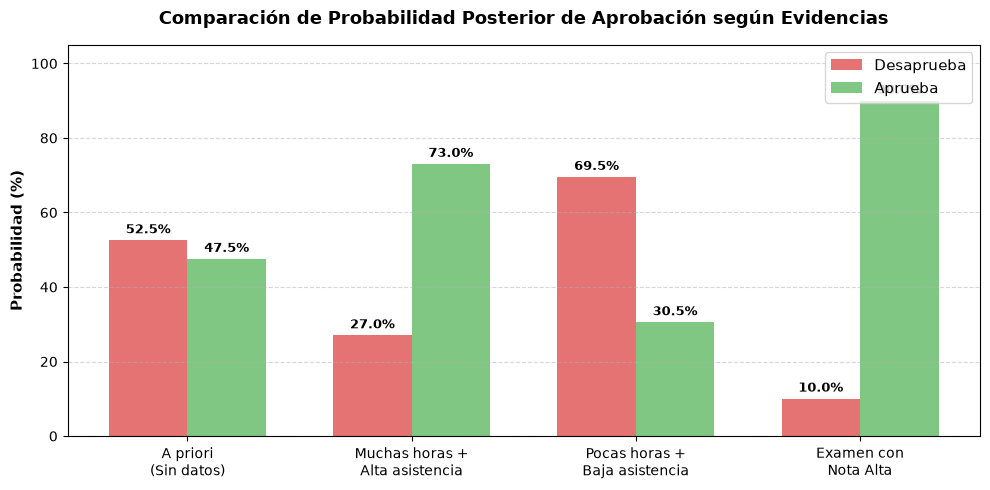

In [6]:
# Gráfico de barras comparativo de los 4 escenarios evaluados
escenarios = [
    "A priori\n(Sin datos)",
    "Muchas horas +\nAlta asistencia",
    "Pocas horas +\nBaja asistencia",
    "Examen con\nNota Alta"
]

# Extracción de valores calculados (Desaprueba vs Aprueba)
prob_desaprueba = [q1.values[0] * 100, q2.values[0] * 100, q3.values[0] * 100, q4.values[0] * 100]
prob_aprueba    = [q1.values[1] * 100, q2.values[1] * 100, q3.values[1] * 100, q4.values[1] * 100]

x = np.arange(len(escenarios))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - ancho/2, prob_desaprueba, ancho, label="Desaprueba", color="#E57373")
rects2 = ax.bar(x + ancho/2, prob_aprueba, ancho, label="Aprueba", color="#81C784")

ax.set_ylabel("Probabilidad (%)", fontsize=11, fontweight="bold")
ax.set_title("Comparación de Probabilidad Posterior de Aprobación según Evidencias", fontsize=13, fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(escenarios, fontsize=10)
ax.set_ylim(0, 105)
ax.legend(loc="upper right", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Etiquetas numéricas sobre cada barra
for rect in rects1:
    h = rect.get_height()
    ax.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                textcoords="offset points", ha="center", va="bottom", fontsize=9, fontweight="bold")

for rect in rects2:
    h = rect.get_height()
    ax.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                textcoords="offset points", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()